# Structure Optimizer Sweep — Cross-Experiment Evaluation

**Date**: 2026-04-23

**Phase 1** (opt_*): Optimizer sweep — AdamW vs SGD vs Adagrad vs RMSprop etc.
**Phase 2** (grid_*): LR × Lambda Group L1 grid — lower structural LR + higher group L1.

**Key questions**:
- Phase 1: Which optimizer escapes the HSIC plateau fastest?
- Phase 2: Does lower structural LR + higher group L1 improve DAG recovery?

In [30]:
import os, json, glob, yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from os.path import join, exists, isdir

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 6)
sns.set_style('whitegrid')

EULER_DIR = join('..', 'experiments', 'tests', 'structure_opt', 'euler')
print(f'Scanning: {os.path.abspath(EULER_DIR)}')

Scanning: c:\Users\ScipioneFrancesco\Documents\Projects\causaliT\experiments\tests\structure_opt\euler


## 1. Auto-Scan & Config Summary

In [31]:
def safe_get(d, *keys, default=None):
    for k in keys:
        if isinstance(d, dict) and k in d:
            d = d[k]
        else:
            return default
    return d

def load_experiment(exp_path, folder_name):
    """Load config + kfold + dag metrics for one experiment."""
    # Config
    cfg_files = glob.glob(join(exp_path, 'config*.yaml'))
    cfg = {}
    if cfg_files:
        with open(cfg_files[0]) as f:
            cfg = yaml.safe_load(f)
    tc = cfg.get('training', {})
    ec = cfg.get('experiment', {})
    
    # Short label from folder name
    label = folder_name.rsplit('_', 1)[0]  # strip job ID
    
    # Phase detection
    phase = 'Phase 1' if label.startswith('opt_') else 'Phase 2'
    
    rec = {
        'exp_name': folder_name,
        'label': label,
        'phase': phase,
        'struct_opt': safe_get(tc, 'structural_optimizer', default='(same)'),
        'struct_lr': safe_get(tc, 'structural_lr', default=None),
        'struct_scheduler': safe_get(tc, 'structural_scheduler', default=None),
        'struct_noise': safe_get(tc, 'structural_gradient_noise', default=0.0),
        'struct_kwargs': str(safe_get(tc, 'structural_optimizer_kwargs', default={})),
        'lambda_group_l1': safe_get(tc, 'lambda_group_l1', default=0.0),
        'lr': safe_get(ec, 'lr', default=safe_get(tc, 'lr')),
        'max_epochs': safe_get(tc, 'max_epochs', default=safe_get(ec, 'max_epochs')),
    }
    
    # Effective structural LR
    rec['eff_struct_lr'] = rec['struct_lr'] if rec['struct_lr'] is not None else rec['lr']
    
    # KFold summary
    kf_path = join(exp_path, 'kfold_summary.json')
    if exists(kf_path):
        with open(kf_path) as f:
            kf = json.load(f)
        stats = kf.get('statistics', {})
        for key in ['test_loss_x', 'test_x_r2', 'test_x_rmse', 'test_x_mae',
                     'test_hsic_cross', 'test_hsic_self', 'test_hsic_reg',
                     'avg_time_per_epoch', 'total_training_time']:
            rec[key] = safe_get(stats, key, 'mean')
    
    # DAG metrics
    dag_path = join(exp_path, 'eval', 'eval_attention_scores', 'files', 'dag_metrics.json')
    if exists(dag_path):
        with open(dag_path) as f:
            dag = json.load(f)
        for key in ['soft_hamming_cross', 'soft_hamming_self', 'mec_distance']:
            rec[f'{key}_mean'] = safe_get(dag, key, 'mean')
            rec[f'{key}_best'] = safe_get(dag, key, 'best')
        rec['mec_membership_rate'] = dag.get('mec_membership_rate')
        # Zeroness
        rec['contrast_cross'] = safe_get(dag, 'zeroness_cross', 'contrast')
        rec['contrast_self'] = safe_get(dag, 'zeroness_self', 'contrast')
        # Per-fold MEC details
        mec_pf = safe_get(dag, 'mec_distance', 'per_fold', default={})
        if mec_pf:
            first = list(mec_pf.values())[0]
            if isinstance(first, dict):
                rec['skeleton_recall'] = first.get('skeleton_recall')
                rec['skeleton_precision'] = first.get('skeleton_precision')
                rec['in_mec'] = first.get('in_mec')
    
    return rec

# Scan
exp_folders = sorted([d for d in os.listdir(EULER_DIR) if isdir(join(EULER_DIR, d))])
records = [load_experiment(join(EULER_DIR, f), f) for f in exp_folders]
df = pd.DataFrame(records)

df_p1 = df[df['phase'] == 'Phase 1'].reset_index(drop=True)
df_p2 = df[df['phase'] == 'Phase 2'].reset_index(drop=True)
print(f'Found {len(df)} experiments: {len(df_p1)} Phase 1 (opt_*), {len(df_p2)} Phase 2 (grid_*)')

# Config view
df[['label', 'phase', 'struct_opt', 'eff_struct_lr', 'lambda_group_l1', 'struct_scheduler', 'struct_noise', 'max_epochs']]

Found 16 experiments: 8 Phase 1 (opt_*), 8 Phase 2 (grid_*)


,label,phase,struct_opt,eff_struct_lr,lambda_group_l1,struct_scheduler,struct_noise,max_epochs
0,grid_lr1e3_lg0_1,Phase 2,None,0.0010,0.1,None,0.00,${experiment.max_epochs}
1,grid_lr1e3_lg0_5,Phase 2,None,0.0010,0.5,None,0.00,${experiment.max_epochs}
2,grid_lr1e4_lg0_0,Phase 2,None,0.0001,0.0,None,0.00,${experiment.max_epochs}
3,grid_lr1e4_lg0_1,Phase 2,None,0.0001,0.1,None,0.00,${experiment.max_epochs}
4,grid_lr1e4_lg0_5,Phase 2,None,0.0001,0.5,None,0.00,${experiment.max_epochs}
5,grid_lr3e4_lg0_0,Phase 2,None,0.0003,0.0,None,0.00,${experiment.max_epochs}
6,grid_lr3e4_lg0_1,Phase 2,None,0.0003,0.1,None,0.00,${experiment.max_epochs}
7,grid_lr3e4_lg0_5,Phase 2,None,0.0003,0.5,None,0.00,${experiment.max_epochs}
8,opt_adagrad,Phase 1,adagrad,0.0100,0.0,None,0.00,${experiment.max_epochs}
9,opt_adam_high_lr,Phase 1,None,0.0100,0.0,None,0.00,${experiment.max_epochs}


---
# PHASE 1: Optimizer Sweep (opt_*)

Which optimizer escapes the HSIC plateau fastest and recovers the true DAG?

## 2. Final Metrics — Bar Chart Comparison (Phase 1)

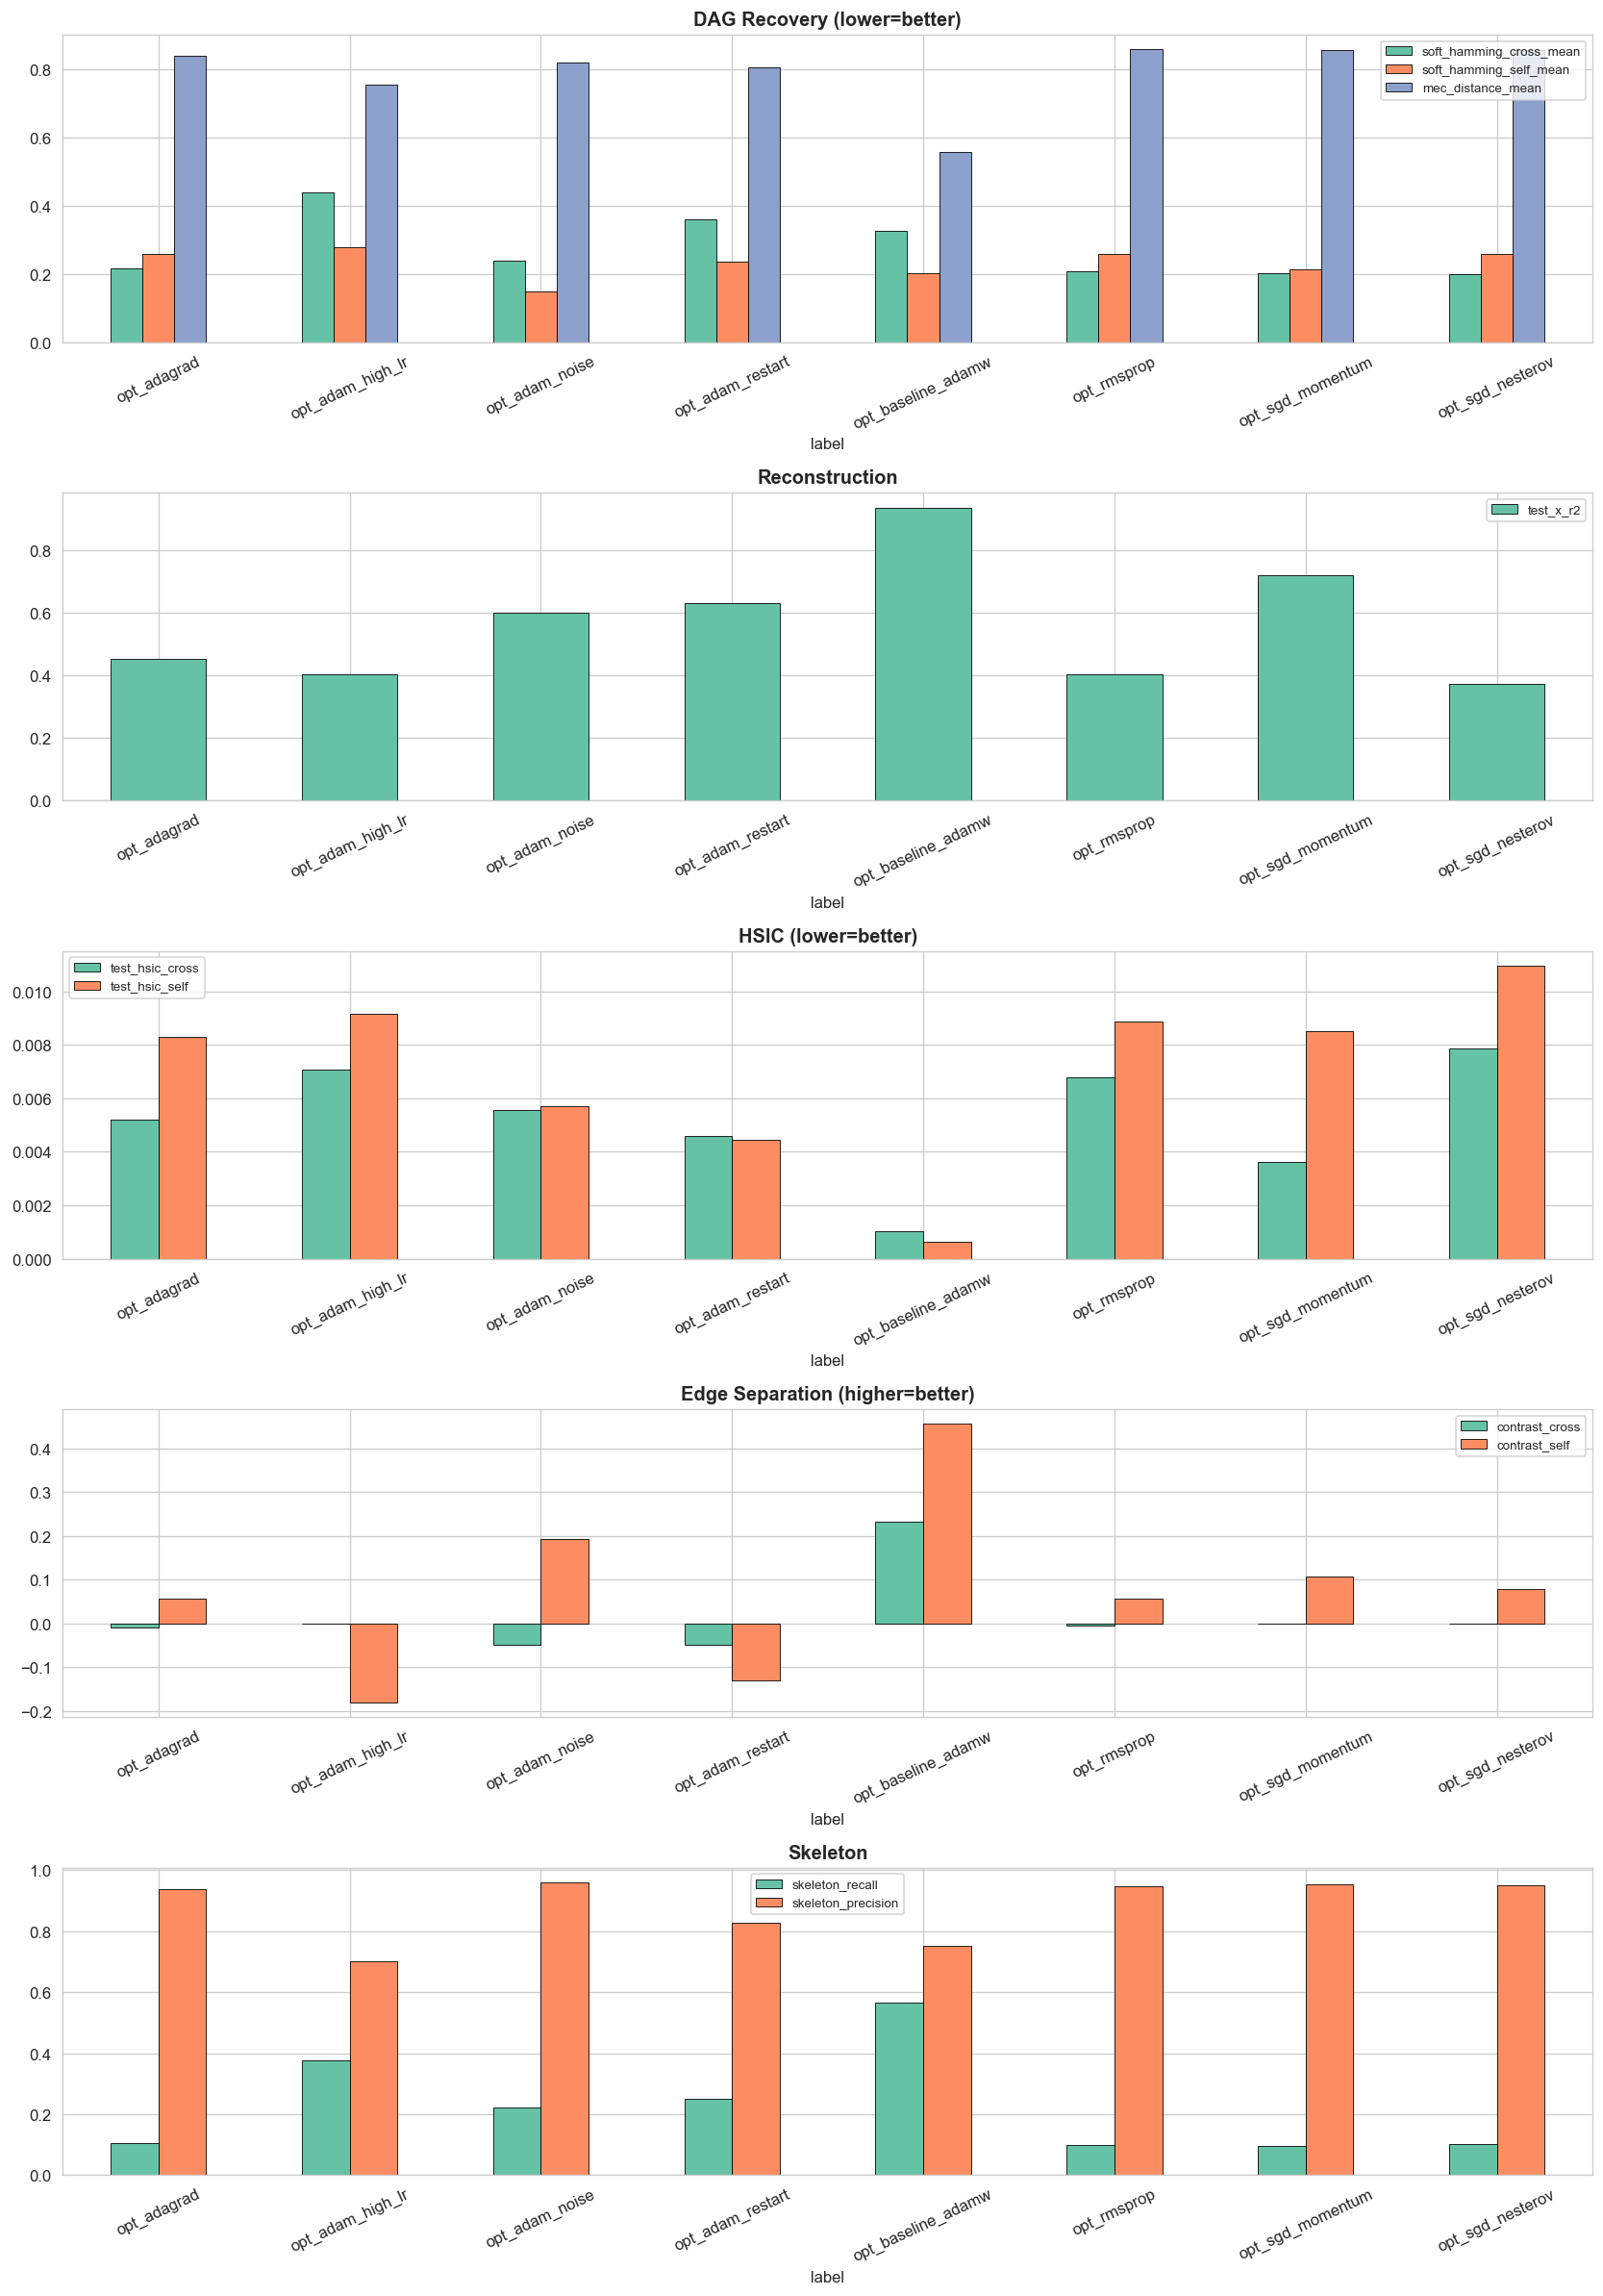

In [32]:
metric_groups = {
    'DAG Recovery (lower=better)': ['soft_hamming_cross_mean', 'soft_hamming_self_mean', 'mec_distance_mean'],
    'Reconstruction': ['test_x_r2'],
    'HSIC (lower=better)': ['test_hsic_cross', 'test_hsic_self'],
    'Edge Separation (higher=better)': ['contrast_cross', 'contrast_self'],
    'Skeleton': ['skeleton_recall', 'skeleton_precision'],
}

fig, axes = plt.subplots(len(metric_groups), 1, figsize=(14, 4 * len(metric_groups)))
colors = sns.color_palette('Set2', len(df_p1))

for ax, (title, metrics) in zip(axes, metric_groups.items()):
    avail = [m for m in metrics if m in df_p1.columns and df_p1[m].notna().any()]
    if not avail:
        ax.set_visible(False)
        continue
    sub = df_p1[['label'] + avail].set_index('label')
    sub.plot(kind='bar', ax=ax, color=colors[:len(avail)], edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

## 3. SHD Evolution — DAG Learning Speed (Phase 1) ⭐

**The key comparison**: overlay SHD trajectories to see which optimizer escapes the plateau first.

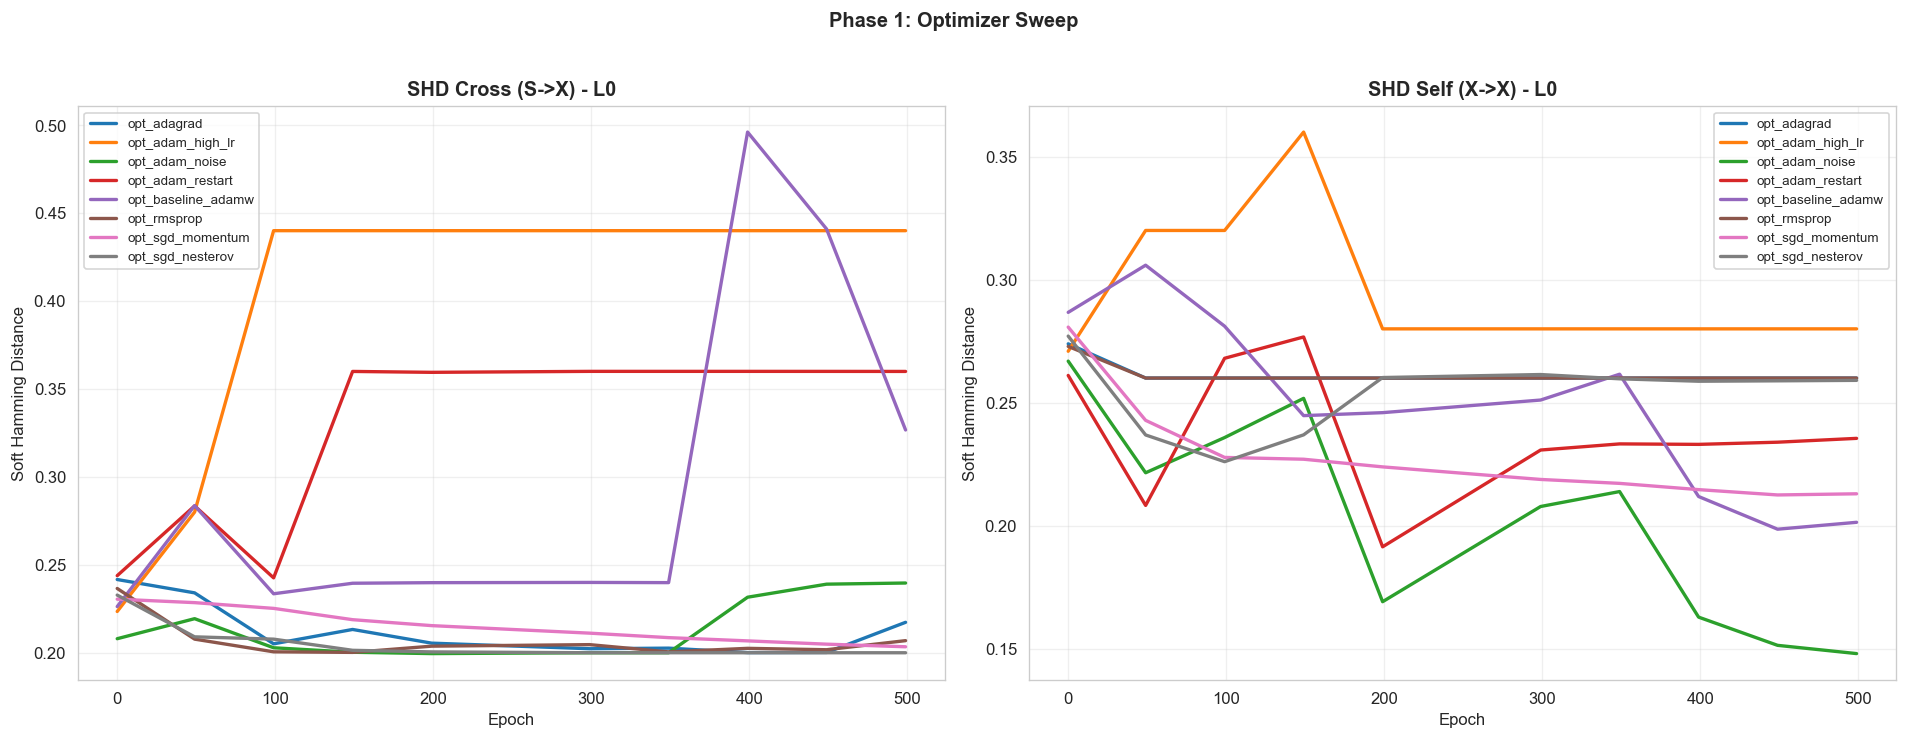

In [33]:
def load_shd_evolution(exp_path):
    """Load SHD evolution from scores_evol.csv."""
    csv_path = join(exp_path, 'eval', 'eval_attention_evolution', 'files', 'scores_evol.csv')
    if not exists(csv_path):
        return None
    evol = pd.read_csv(csv_path)
    cols_of_interest = ['epoch']
    for c in ['shd_cross_L0', 'shd_cross_L1', 'shd_self_L0', 'shd_self_L1']:
        if c in evol.columns:
            cols_of_interest.append(c)
    return evol[cols_of_interest].copy()

def load_training_logs(exp_path, fold='k_0'):
    csv_dir = join(exp_path, fold, 'logs', 'csv')
    if not exists(csv_dir):
        return None
    versions = sorted(os.listdir(csv_dir))
    if not versions:
        return None
    path = join(csv_dir, versions[-1], 'metrics.csv')
    if not exists(path):
        return None
    return pd.read_csv(path).groupby('epoch').first().reset_index()

cmap = plt.cm.tab10

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, row in df_p1.iterrows():
    evol = load_shd_evolution(join(EULER_DIR, row['exp_name']))
    if evol is None:
        continue
    color = cmap(i)
    label = row['label']
    if 'shd_cross_L0' in evol.columns:
        axes[0].plot(evol['epoch'], evol['shd_cross_L0'], label=label, color=color, linewidth=2)
    if 'shd_self_L0' in evol.columns:
        axes[1].plot(evol['epoch'], evol['shd_self_L0'], label=label, color=color, linewidth=2)

for ax, title in zip(axes, ['SHD Cross (S->X) - L0', 'SHD Self (X->X) - L0']):
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Soft Hamming Distance')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Phase 1: Optimizer Sweep', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Plateau Escape Analysis (Phase 1)
Find the first epoch where SHD drops below 90% of its initial value.

In [34]:
def compute_escape_table(df_subset):
    escape_records = []
    for _, row in df_subset.iterrows():
        evol = load_shd_evolution(join(EULER_DIR, row['exp_name']))
        if evol is None:
            continue
        rec = {'label': row['label']}
        for col in ['shd_cross_L0', 'shd_self_L0']:
            if col not in evol.columns:
                continue
            vals = evol[col].values
            initial = vals[0] if len(vals) > 0 else 1.0
            threshold = 0.9 * initial
            escaped = np.where(vals < threshold)[0]
            rec[f'{col}_escape_epoch'] = int(evol['epoch'].iloc[escaped[0]]) if len(escaped) > 0 else None
            rec[f'{col}_final'] = float(vals[-1]) if len(vals) > 0 else None
            rec[f'{col}_initial'] = float(initial)
            rec[f'{col}_improvement'] = float(initial - vals[-1]) if len(vals) > 0 else 0
        escape_records.append(rec)
    return pd.DataFrame(escape_records)

df_escape_p1 = compute_escape_table(df_p1)
df_escape_p1

,label,shd_cross_L0_escape_epoch,shd_cross_L0_final,shd_cross_L0_initial,shd_cross_L0_improvement,shd_self_L0_escape_epoch,shd_self_L0_final,shd_self_L0_initial,shd_self_L0_improvement
0,opt_adagrad,99.0,0.217304,0.241642,0.024338,NaN,0.260000,0.273918,0.013918
1,opt_adam_high_lr,NaN,0.440000,0.223461,-0.216539,NaN,0.280000,0.270898,-0.009102
2,opt_adam_noise,NaN,0.239648,0.207981,-0.031667,49.0,0.147991,0.266884,0.118893
3,opt_adam_restart,NaN,0.359960,0.243830,-0.116130,49.0,0.235486,0.261067,0.025582
4,opt_baseline_adamw,NaN,0.326672,0.226243,-0.100429,149.0,0.201361,0.286706,0.085345
5,opt_rmsprop,49.0,0.206881,0.236548,0.029667,NaN,0.260000,0.272862,0.012862
6,opt_sgd_momentum,399.0,0.203397,0.230464,0.027067,49.0,0.212951,0.280713,0.067762
7,opt_sgd_nesterov,49.0,0.200000,0.232790,0.032790,49.0,0.259064,0.277060,0.017996


## 4. Training Curve Comparison (Phase 1)

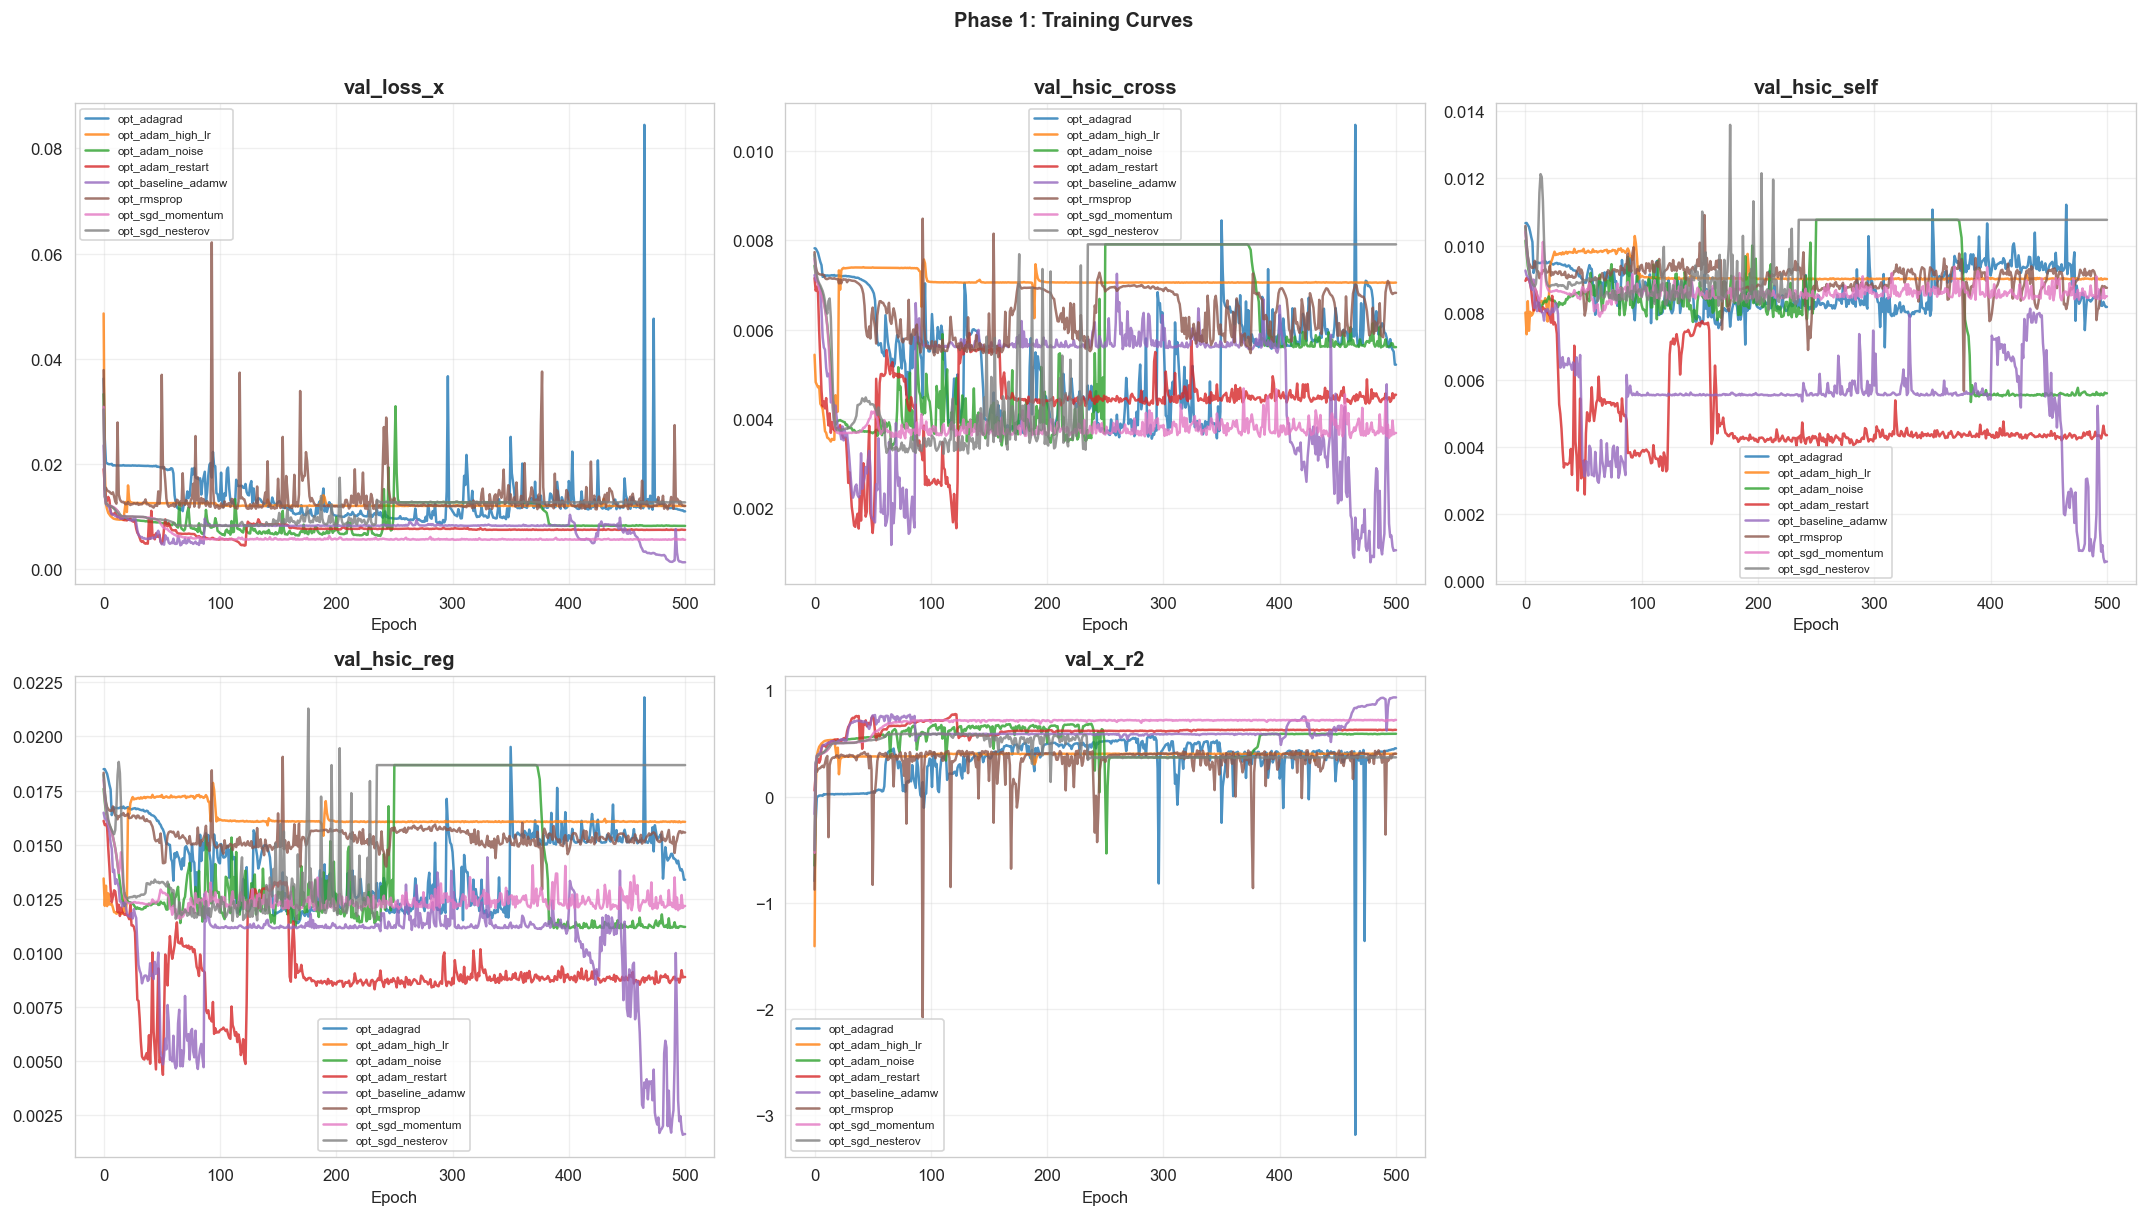

In [35]:
train_metrics = ['val_loss_x', 'val_hsic_cross', 'val_hsic_self', 'val_hsic_reg', 'val_x_r2']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for mi, metric in enumerate(train_metrics):
    ax = axes[mi]
    for i, row in df_p1.iterrows():
        logs = load_training_logs(join(EULER_DIR, row['exp_name']))
        if logs is not None and metric in logs.columns:
            ax.plot(logs['epoch'], logs[metric], label=row['label'], color=cmap(i), alpha=0.8)
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

axes[-1].set_visible(False)
plt.suptitle('Phase 1: Training Curves', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Final Attention Score Heatmaps (Phase 1)

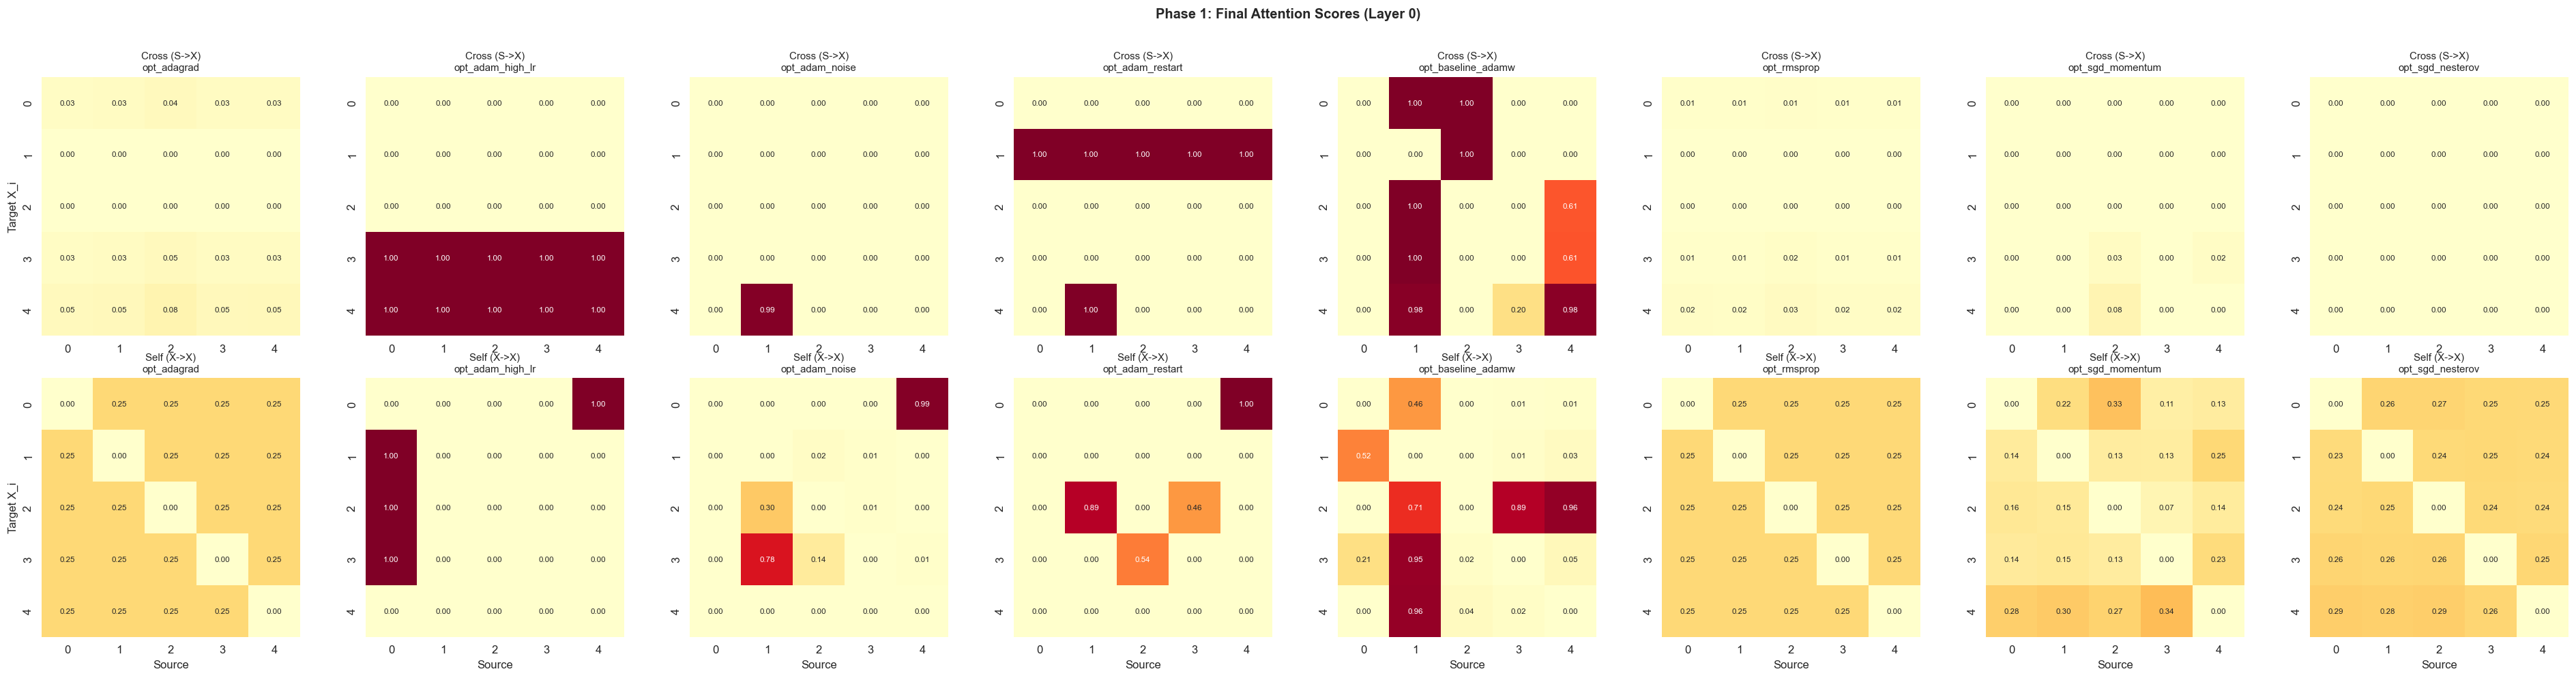

In [36]:
def extract_final_scores(exp_path, att_type='dec_cross', layer='L0'):
    """Extract final-epoch attention scores as NxN matrix from scores_evol.csv."""
    csv_path = join(exp_path, 'eval', 'eval_attention_evolution', 'files', 'scores_evol.csv')
    if not exists(csv_path):
        return None
    evol = pd.read_csv(csv_path)
    last_row = evol.iloc[-1]
    
    # Find columns matching pattern: dec_cross_L0_ij_mean
    prefix = f'{att_type}_{layer}_' if layer else f'{att_type}_'
    score_cols = [c for c in evol.columns if c.startswith(prefix) and c.endswith('_mean') and 'diff' not in c]
    if not score_cols:
        prefix = f'{att_type}_'
        score_cols = [c for c in evol.columns if c.startswith(prefix) and c.endswith('_mean') and 'diff' not in c and '_L' not in c]
    
    if not score_cols:
        return None
    
    # Parse ij indices
    n = int(np.sqrt(len(score_cols)))
    mat = np.zeros((n, n))
    for col in score_cols:
        parts = col.replace(prefix, '').replace('_mean', '')
        if len(parts) == 2 and parts.isdigit():
            i, j = int(parts[0]), int(parts[1])
            if i < n and j < n:
                mat[i, j] = last_row[col]
    return mat

n_p1 = len(df_p1)
fig, axes = plt.subplots(2, n_p1, figsize=(4 * n_p1, 8))
if n_p1 == 1:
    axes = axes.reshape(2, 1)

for i, row in df_p1.iterrows():
    exp_path = join(EULER_DIR, row['exp_name'])
    for j, (att_type, title_prefix) in enumerate([('dec_cross', 'Cross (S->X)'), ('dec_self', 'Self (X->X)')]):
        ax = axes[j, i]
        mat = extract_final_scores(exp_path, att_type, 'L0')
        if mat is not None:
            sns.heatmap(mat, ax=ax, vmin=0, vmax=1, cmap='YlOrRd', annot=True, fmt='.2f',
                        square=True, cbar=False, annot_kws={'fontsize': 7})
        ax.set_title(f"{title_prefix}\n{row['label']}", fontsize=9)
        if i == 0:
            ax.set_ylabel('Target X_i')
        if j == 1:
            ax.set_xlabel('Source')

plt.suptitle('Phase 1: Final Attention Scores (Layer 0)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Phase 1 Summary Ranking Table

In [37]:
summary_cols = [
    'label', 'struct_opt',
    'soft_hamming_cross_mean', 'soft_hamming_self_mean', 'mec_distance_mean',
    'skeleton_recall', 'skeleton_precision', 'contrast_cross', 'contrast_self',
    'test_x_r2', 'test_hsic_cross', 'test_hsic_self',
    'avg_time_per_epoch',
]
avail = [c for c in summary_cols if c in df_p1.columns]
summary = df_p1[avail].sort_values('mec_distance_mean' if 'mec_distance_mean' in avail else 'label')
summary.round(4).style.background_gradient(
    subset=[c for c in ['soft_hamming_cross_mean', 'soft_hamming_self_mean', 'mec_distance_mean'] if c in avail],
    cmap='RdYlGn_r'
).background_gradient(
    subset=[c for c in ['skeleton_recall', 'test_x_r2', 'contrast_cross', 'contrast_self'] if c in avail],
    cmap='RdYlGn'
)

,label,struct_opt,soft_hamming_cross_mean,soft_hamming_self_mean,mec_distance_mean,skeleton_recall,skeleton_precision,contrast_cross,contrast_self,test_x_r2,test_hsic_cross,test_hsic_self,avg_time_per_epoch
4,opt_baseline_adamw,None,0.326700,0.201400,0.557800,0.566300,0.753500,0.233500,0.457800,0.934900,0.001000,0.000600,9.285100
1,opt_adam_high_lr,None,0.440000,0.280000,0.755500,0.375000,0.702700,-0.000000,-0.181800,0.401300,0.007100,0.009200,9.380600
3,opt_adam_restart,None,0.360000,0.235500,0.808100,0.250000,0.826500,-0.050000,-0.131200,0.631100,0.004600,0.004400,9.293000
2,opt_adam_noise,None,0.239600,0.148000,0.819700,0.221800,0.960900,-0.049600,0.193900,0.599000,0.005600,0.005700,9.363700
0,opt_adagrad,adagrad,0.217300,0.260000,0.841100,0.104900,0.938600,-0.008300,0.056800,0.452300,0.005200,0.008300,9.010200
6,opt_sgd_momentum,sgd,0.203400,0.213000,0.857400,0.094800,0.954500,-0.001000,0.106500,0.718400,0.003600,0.008500,9.383400
7,opt_sgd_nesterov,sgd,0.200000,0.259100,0.858000,0.103100,0.949900,0.000000,0.079400,0.371400,0.007900,0.011000,9.566700
5,opt_rmsprop,rmsprop,0.206900,0.260000,0.859800,0.097600,0.947200,-0.004000,0.056800,0.403700,0.006800,0.008900,9.287300


---
# PHASE 2: LR x Lambda Group Grid (grid_*)

Based on Phase 1 findings:
- AdamW is the best optimizer (adaptive per-param LR crucial for edge reversal)
- Sparsity + reconstruction drive SHD, HSIC is a coarse corrector
- Lower structural LR + higher Group L1 may improve DAG recovery

## 7. Phase 2 Config Overview

In [38]:
# Add baseline to Phase 2 for comparison
baseline_row = df_p1[df_p1['label'] == 'opt_baseline_adamw']
if len(baseline_row) > 0:
    df_p2_full = pd.concat([baseline_row, df_p2], ignore_index=True)
    df_p2_full.loc[df_p2_full['label'] == 'opt_baseline_adamw', 'label'] = 'baseline (ref)'
else:
    df_p2_full = df_p2.copy()

df_p2_full[['label', 'eff_struct_lr', 'lambda_group_l1', 'max_epochs']]

,label,eff_struct_lr,lambda_group_l1,max_epochs
0,baseline (ref),0.0010,0.0,${experiment.max_epochs}
1,grid_lr1e3_lg0_1,0.0010,0.1,${experiment.max_epochs}
2,grid_lr1e3_lg0_5,0.0010,0.5,${experiment.max_epochs}
3,grid_lr1e4_lg0_0,0.0001,0.0,${experiment.max_epochs}
4,grid_lr1e4_lg0_1,0.0001,0.1,${experiment.max_epochs}
5,grid_lr1e4_lg0_5,0.0001,0.5,${experiment.max_epochs}
6,grid_lr3e4_lg0_0,0.0003,0.0,${experiment.max_epochs}
7,grid_lr3e4_lg0_1,0.0003,0.1,${experiment.max_epochs}
8,grid_lr3e4_lg0_5,0.0003,0.5,${experiment.max_epochs}


## 8. 2D Heatmaps: LR x Lambda_Group ⭐⭐

The main result: which (structural_lr, lambda_group_l1) combination gives best DAG recovery?

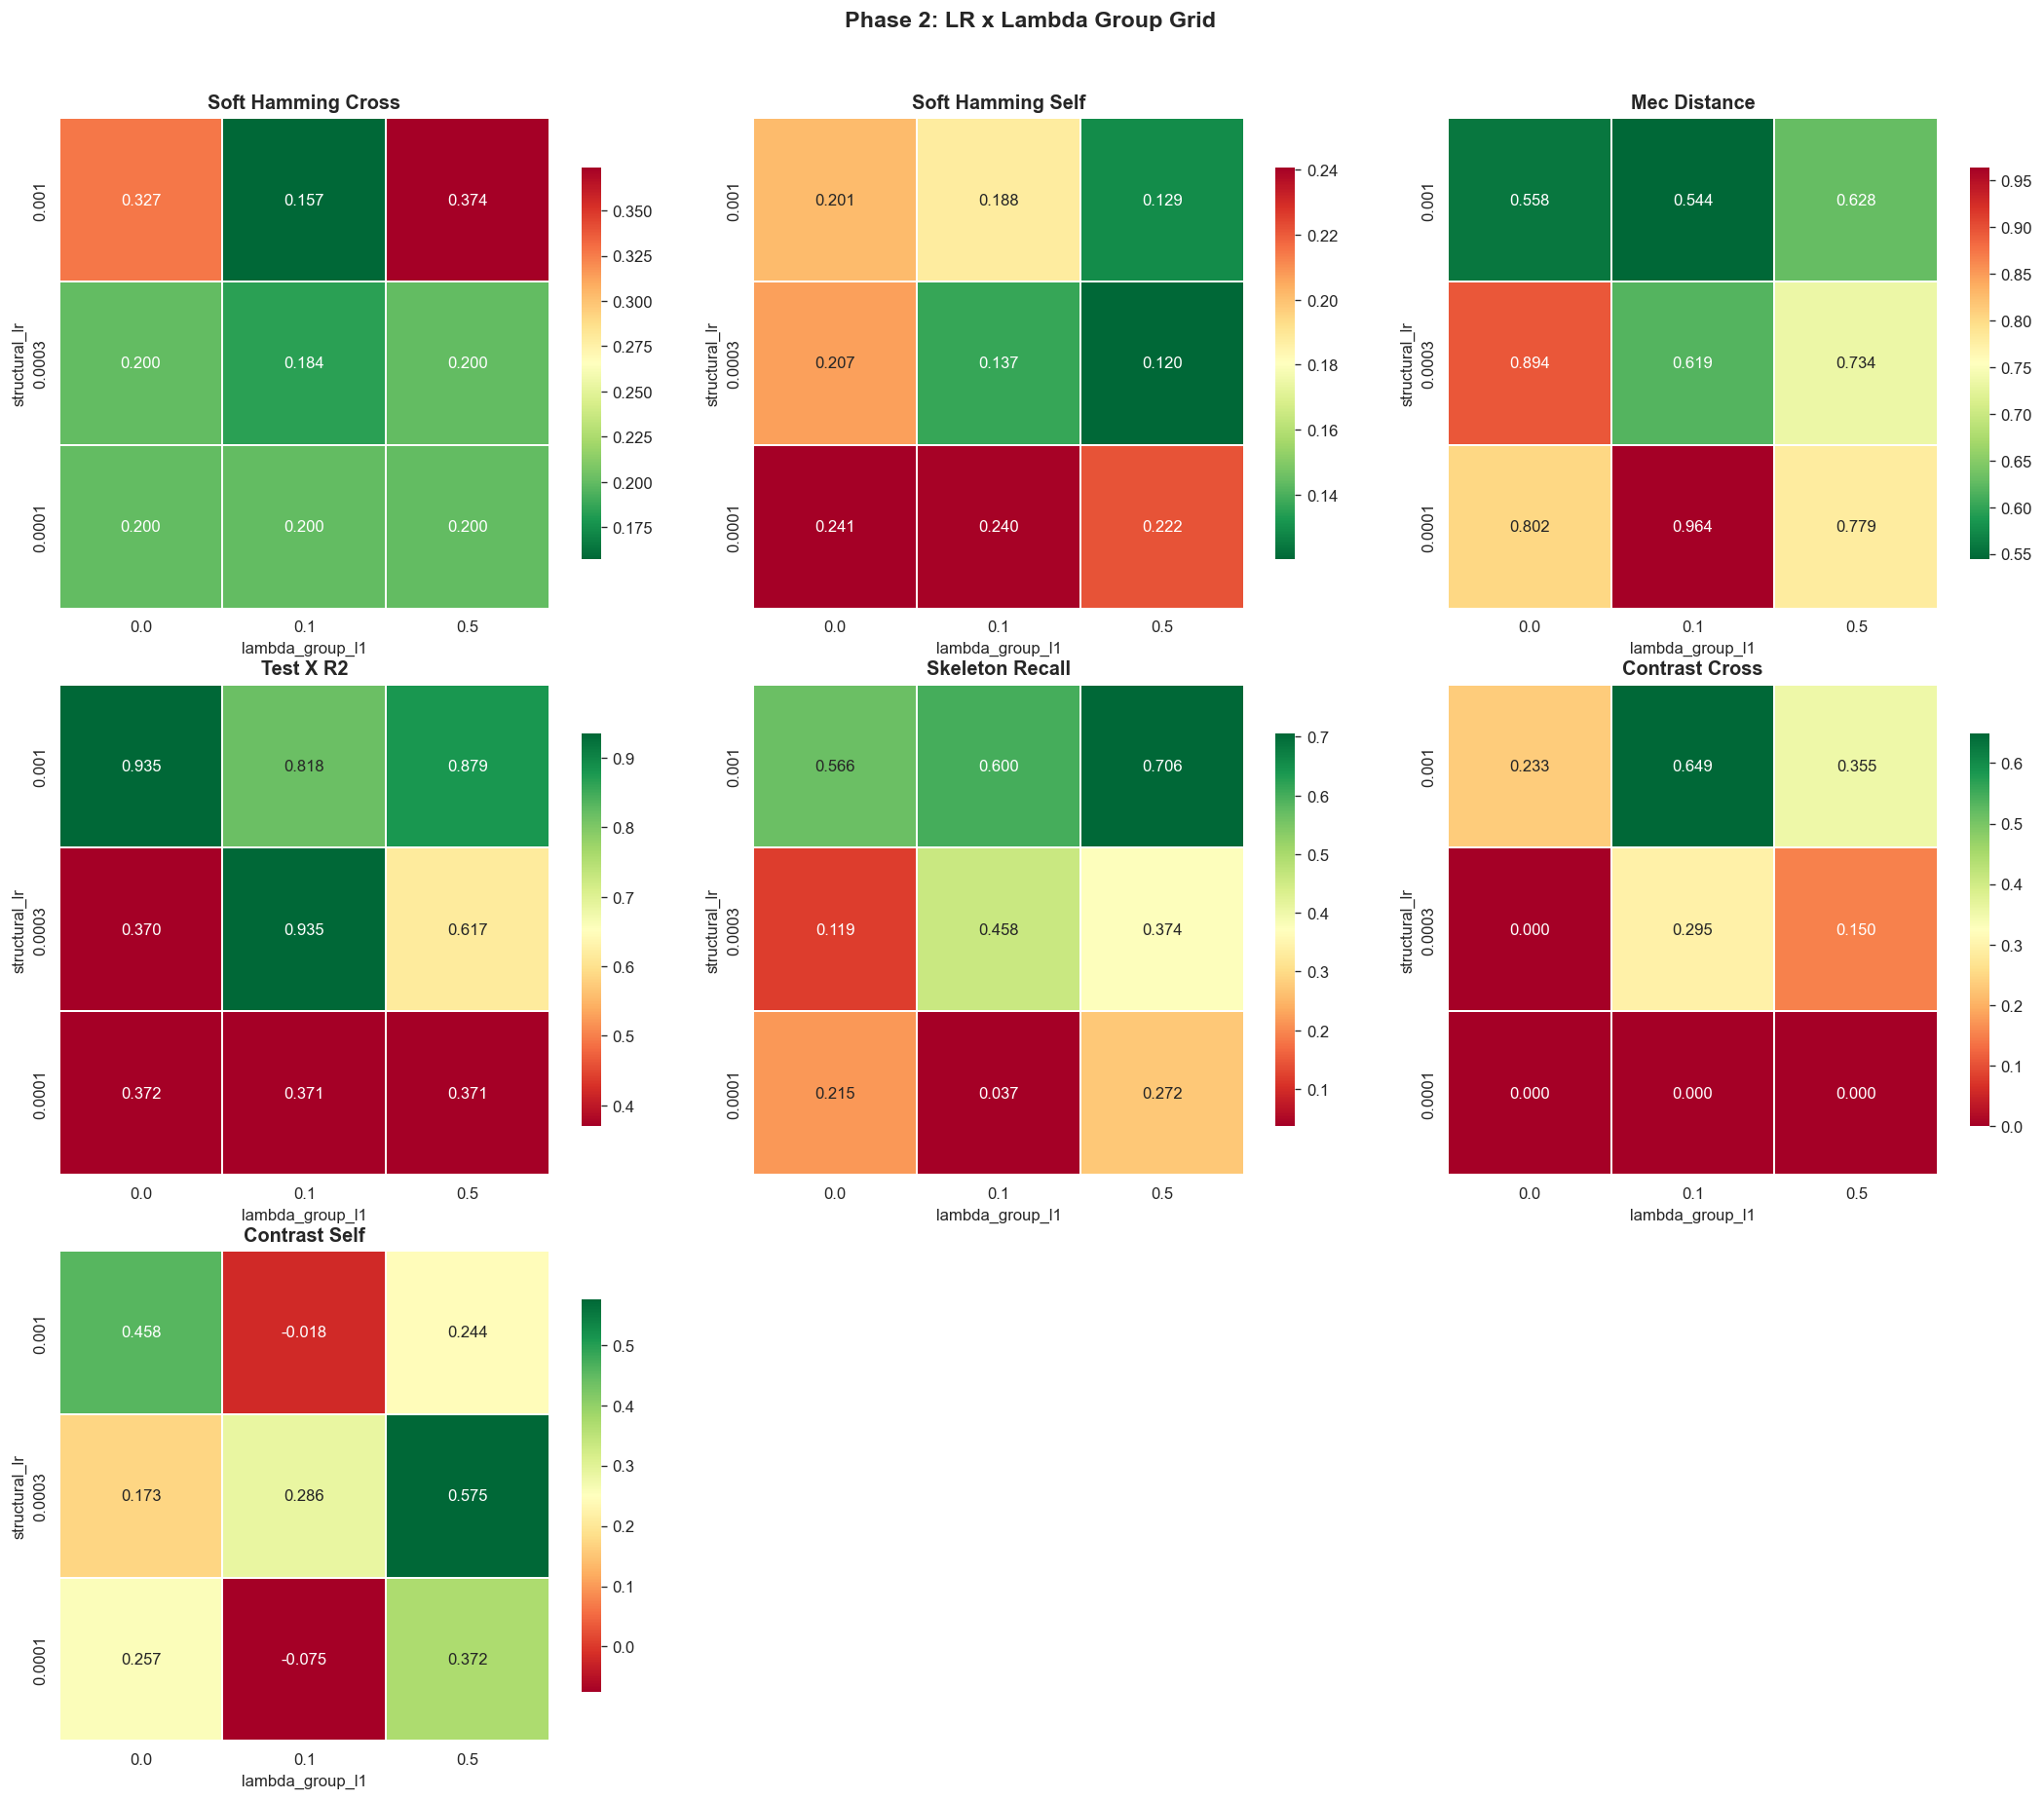

In [39]:
# Build a pivot-ready dataframe
pivot_metrics = ['soft_hamming_cross_mean', 'soft_hamming_self_mean', 'mec_distance_mean',
                 'test_x_r2', 'skeleton_recall', 'contrast_cross', 'contrast_self']

avail_metrics = [m for m in pivot_metrics if m in df_p2_full.columns and df_p2_full[m].notna().any()]
n_metrics = len(avail_metrics)
ncols = min(3, n_metrics)
nrows = (n_metrics + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.array(axes).flatten() if n_metrics > 1 else [axes]

for idx, metric in enumerate(avail_metrics):
    ax = axes[idx]
    try:
        pivot = df_p2_full.pivot_table(
            index='eff_struct_lr', columns='lambda_group_l1', values=metric, aggfunc='first'
        ).sort_index(ascending=False)
        
        # Choose colormap direction
        lower_better = any(x in metric for x in ['hamming', 'mec_distance', 'hsic'])
        cmap_choice = 'RdYlGn_r' if lower_better else 'RdYlGn'
        
        sns.heatmap(pivot, ax=ax, annot=True, fmt='.3f', cmap=cmap_choice,
                    square=True, linewidths=1, linecolor='white',
                    cbar_kws={'shrink': 0.8})
        ax.set_title(metric.replace('_mean', '').replace('_', ' ').title(), fontweight='bold')
        ax.set_xlabel('lambda_group_l1')
        ax.set_ylabel('structural_lr')
    except Exception as e:
        ax.text(0.5, 0.5, f'Error: {e}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(metric)

for j in range(n_metrics, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Phase 2: LR x Lambda Group Grid', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9. SHD Evolution — Phase 2 Grid

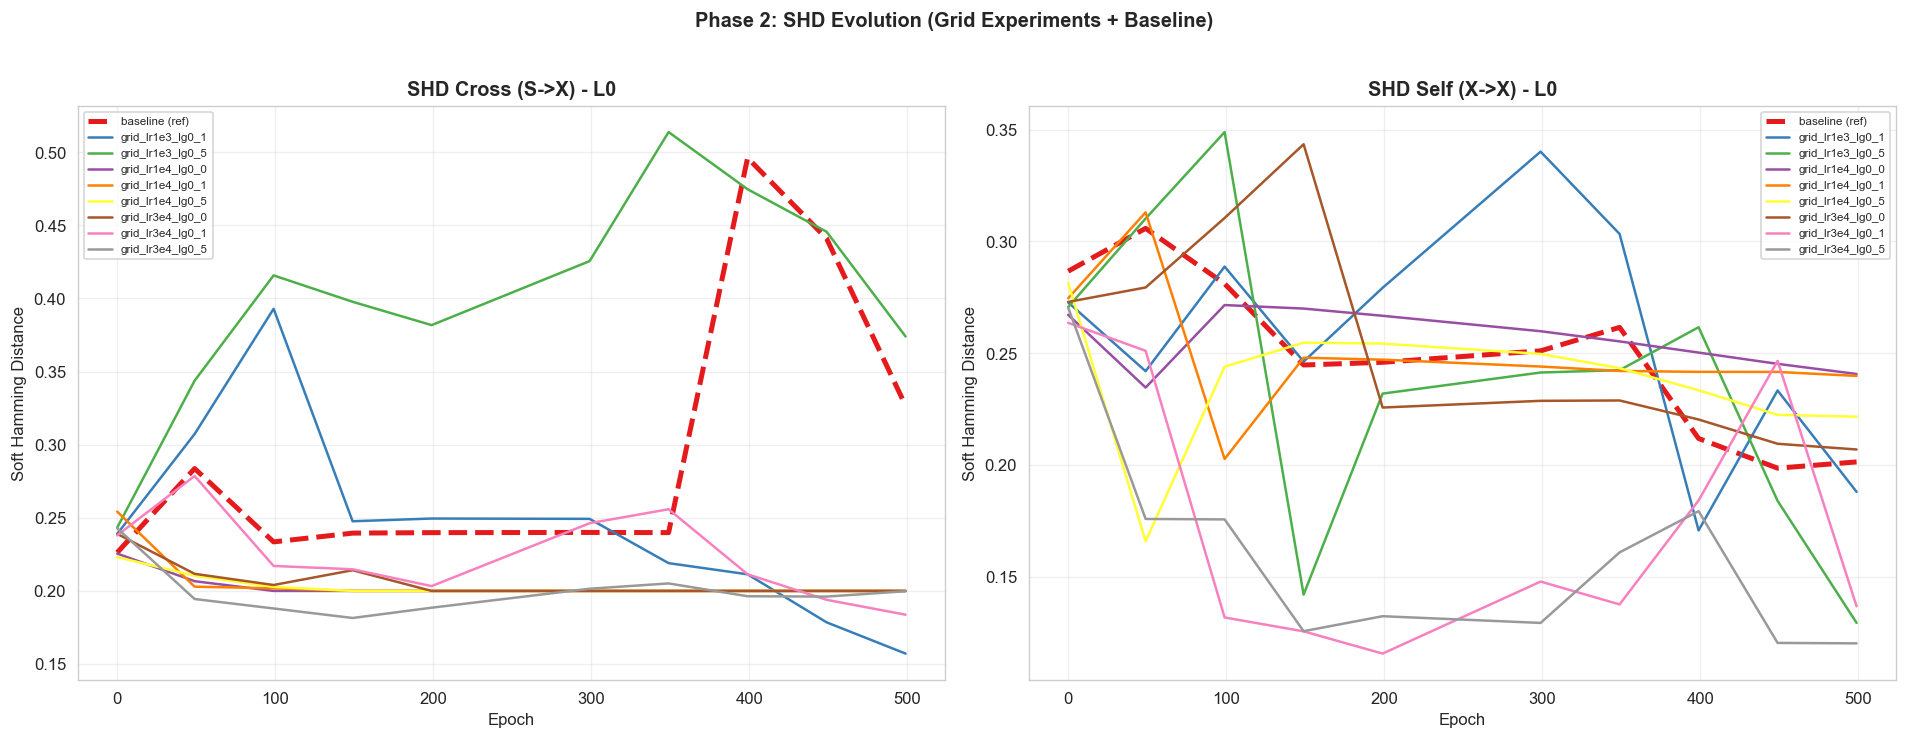

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cmap_p2 = plt.cm.Set1

for i, row in df_p2_full.iterrows():
    evol = load_shd_evolution(join(EULER_DIR, row['exp_name']))
    if evol is None:
        continue
    color = cmap_p2(i % 9)
    label = row['label']
    lw = 3 if 'baseline' in label else 1.5
    ls = '--' if 'baseline' in label else '-'
    if 'shd_cross_L0' in evol.columns:
        axes[0].plot(evol['epoch'], evol['shd_cross_L0'], label=label, color=color, linewidth=lw, linestyle=ls)
    if 'shd_self_L0' in evol.columns:
        axes[1].plot(evol['epoch'], evol['shd_self_L0'], label=label, color=color, linewidth=lw, linestyle=ls)

for ax, title in zip(axes, ['SHD Cross (S->X) - L0', 'SHD Self (X->X) - L0']):
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Soft Hamming Distance')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Phase 2: SHD Evolution (Grid Experiments + Baseline)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Plateau Escape Analysis (Phase 2)

In [41]:
df_escape_p2 = compute_escape_table(df_p2_full)
df_escape_p2

,label,shd_cross_L0_escape_epoch,shd_cross_L0_final,shd_cross_L0_initial,shd_cross_L0_improvement,shd_self_L0_escape_epoch,shd_self_L0_final,shd_self_L0_initial,shd_self_L0_improvement
0,baseline (ref),NaN,0.326672,0.226243,-0.100429,149,0.201361,0.286706,0.085345
1,grid_lr1e3_lg0_1,399.0,0.157154,0.238999,0.081845,49,0.187970,0.272722,0.084752
2,grid_lr1e3_lg0_5,NaN,0.373977,0.243288,-0.130689,149,0.129333,0.270693,0.141360
3,grid_lr1e4_lg0_0,99.0,0.200000,0.225545,0.025545,49,0.240710,0.267188,0.026479
4,grid_lr1e4_lg0_1,49.0,0.200000,0.254223,0.054223,99,0.239847,0.274608,0.034761
5,grid_lr1e4_lg0_5,149.0,0.200000,0.223135,0.023135,49,0.221585,0.281419,0.059835
6,grid_lr3e4_lg0_0,49.0,0.200000,0.239005,0.039005,199,0.206927,0.272952,0.066024
7,grid_lr3e4_lg0_1,199.0,0.183750,0.238018,0.054269,99,0.136792,0.263597,0.126805
8,grid_lr3e4_lg0_5,49.0,0.199805,0.242835,0.043030,49,0.120175,0.270387,0.150212


## 10. Training Curves (Phase 2)

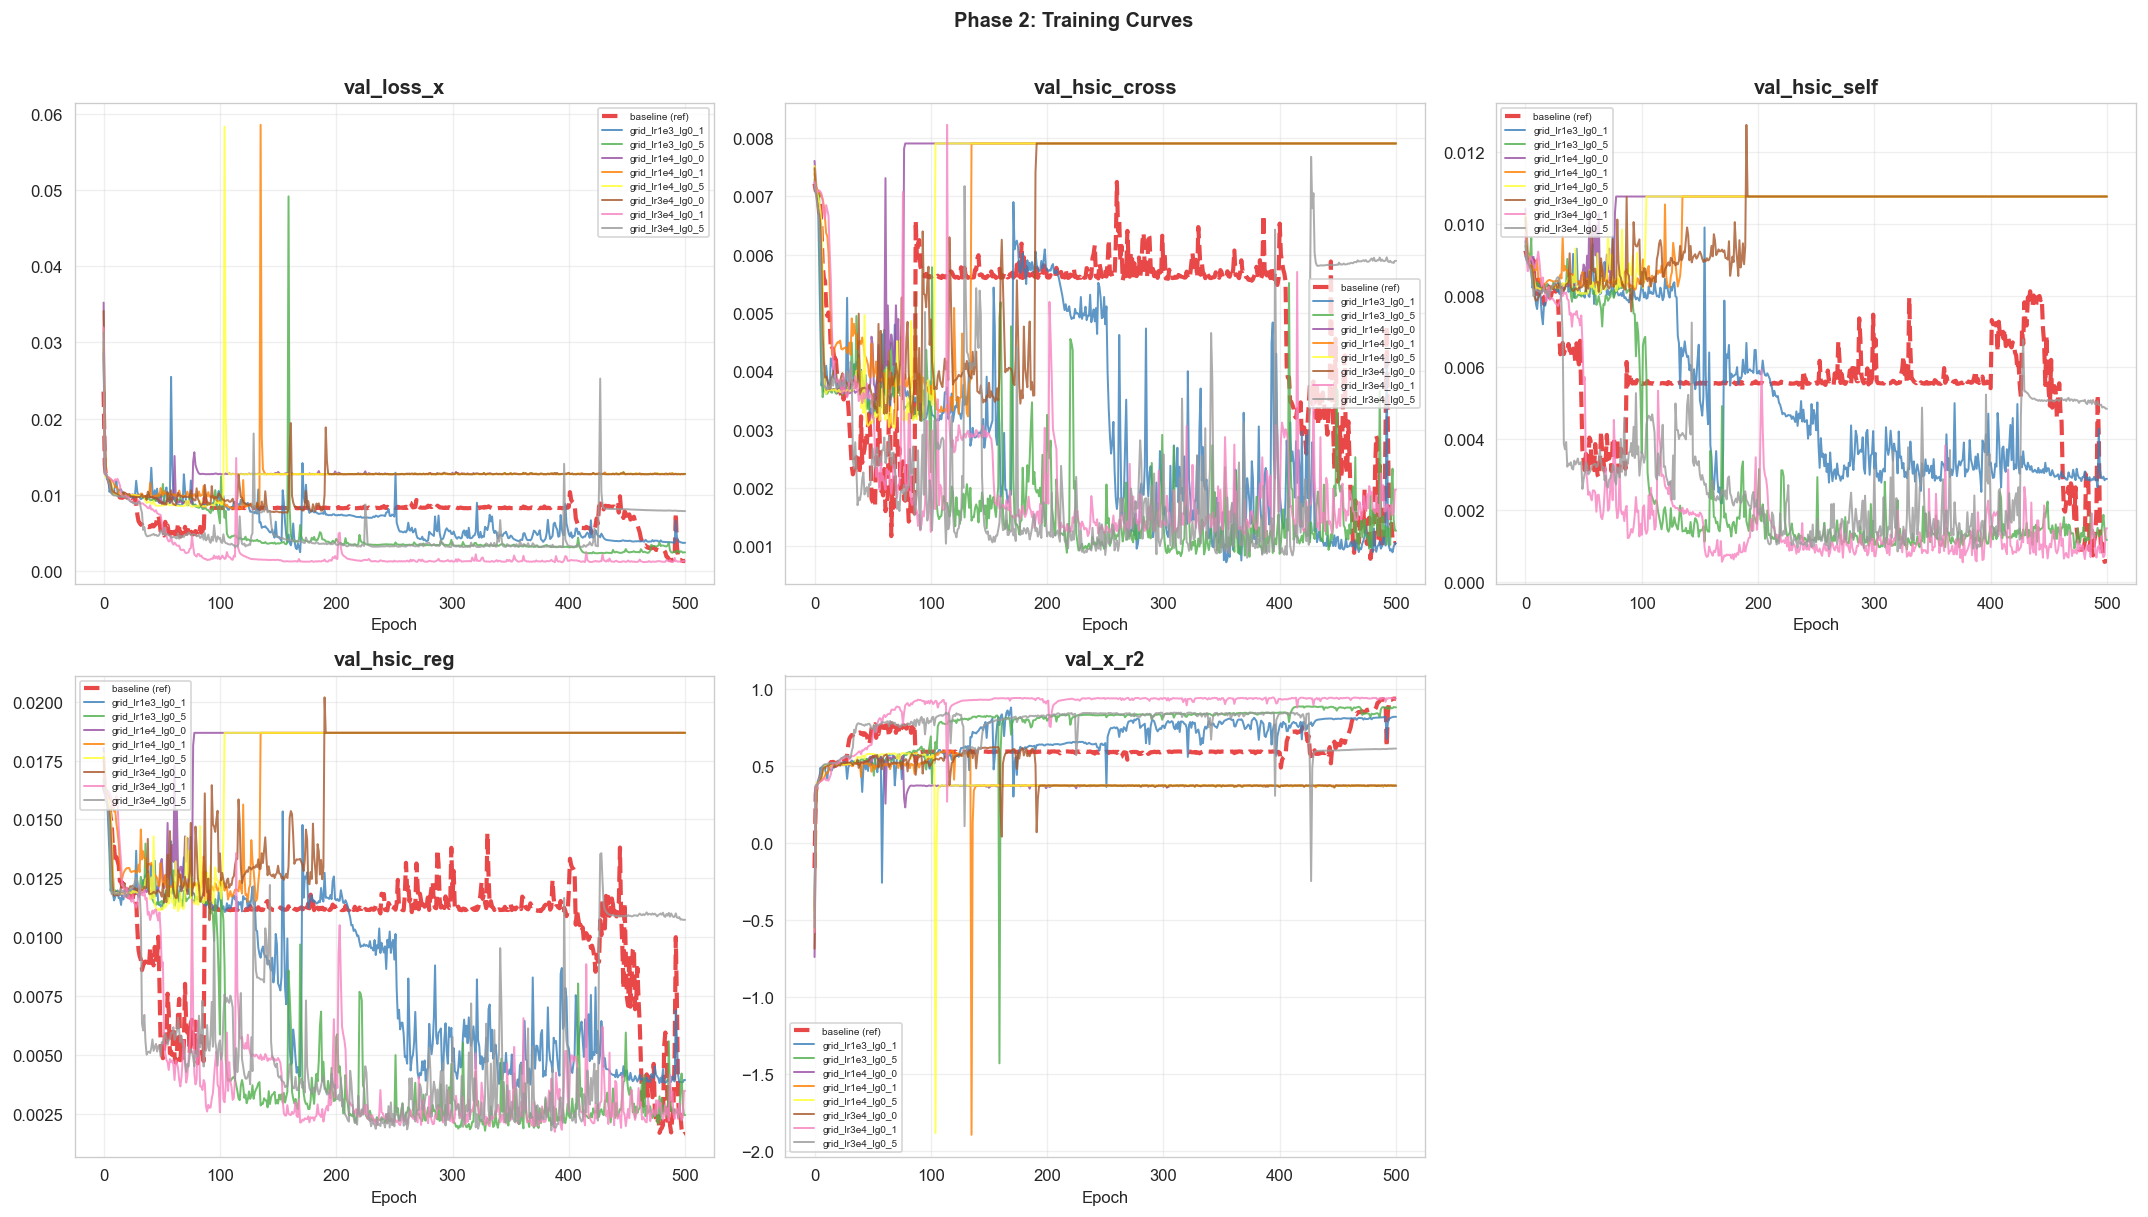

In [42]:
train_metrics = ['val_loss_x', 'val_hsic_cross', 'val_hsic_self', 'val_hsic_reg', 'val_x_r2']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for mi, metric in enumerate(train_metrics):
    ax = axes_flat[mi]
    for i, row in df_p2_full.iterrows():
        logs = load_training_logs(join(EULER_DIR, row['exp_name']))
        if logs is not None and metric in logs.columns:
            lw = 2.5 if 'baseline' in row['label'] else 1.2
            ls = '--' if 'baseline' in row['label'] else '-'
            ax.plot(logs['epoch'], logs[metric], label=row['label'], color=cmap_p2(i % 9), 
                    alpha=0.8, linewidth=lw, linestyle=ls)
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)

axes_flat[-1].set_visible(False)
plt.suptitle('Phase 2: Training Curves', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 11. Final Attention Score Heatmaps (Phase 2)

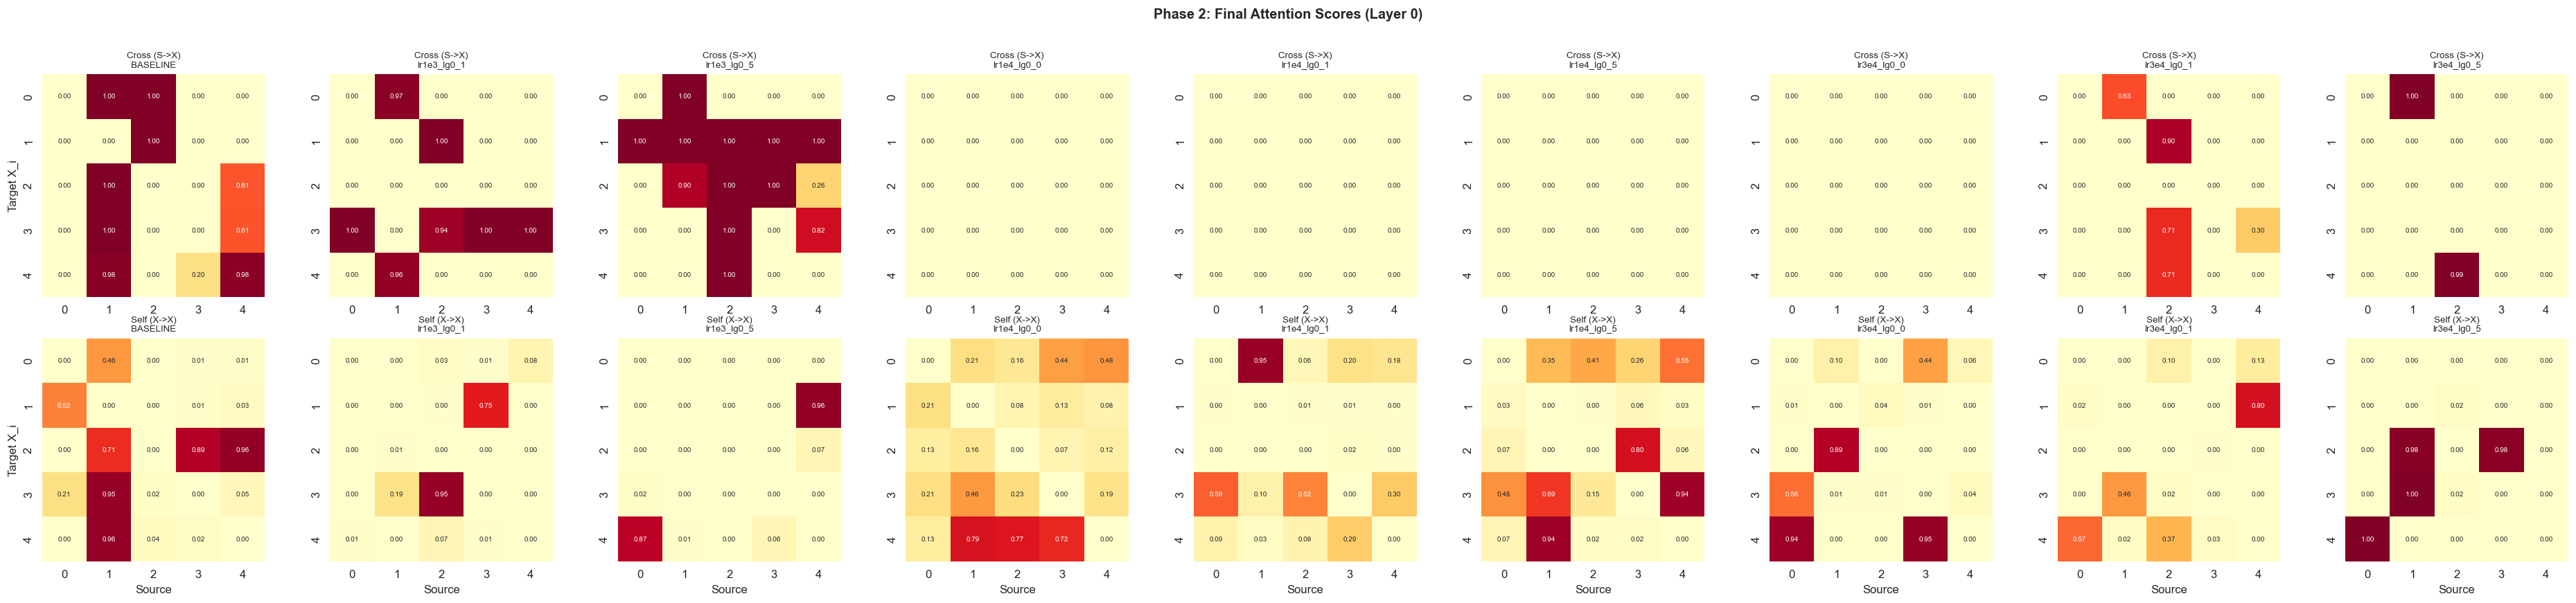

In [43]:
n_p2 = len(df_p2_full)
fig, axes = plt.subplots(2, n_p2, figsize=(3.5 * n_p2, 7))
if n_p2 == 1:
    axes = axes.reshape(2, 1)

for i, row in df_p2_full.iterrows():
    exp_path = join(EULER_DIR, row['exp_name'])
    for j, (att_type, title_prefix) in enumerate([('dec_cross', 'Cross (S->X)'), ('dec_self', 'Self (X->X)')]):
        ax = axes[j, i]
        mat = extract_final_scores(exp_path, att_type, 'L0')
        if mat is not None:
            sns.heatmap(mat, ax=ax, vmin=0, vmax=1, cmap='YlOrRd', annot=True, fmt='.2f',
                        square=True, cbar=False, annot_kws={'fontsize': 6})
        short_label = row['label'].replace('grid_', '').replace('baseline (ref)', 'BASELINE')
        ax.set_title(f"{title_prefix}\n{short_label}", fontsize=8)
        if i == 0:
            ax.set_ylabel('Target X_i')
        if j == 1:
            ax.set_xlabel('Source')

plt.suptitle('Phase 2: Final Attention Scores (Layer 0)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 12. Phase 2 Summary Ranking Table

In [44]:
summary_cols_p2 = [
    'label', 'eff_struct_lr', 'lambda_group_l1',
    'soft_hamming_cross_mean', 'soft_hamming_self_mean', 'mec_distance_mean',
    'skeleton_recall', 'skeleton_precision', 'contrast_cross', 'contrast_self',
    'test_x_r2', 'test_hsic_cross', 'test_hsic_self',
    'avg_time_per_epoch',
]
avail_p2 = [c for c in summary_cols_p2 if c in df_p2_full.columns]
summary_p2 = df_p2_full[avail_p2].sort_values('mec_distance_mean' if 'mec_distance_mean' in avail_p2 else 'label')
summary_p2.round(4).style.background_gradient(
    subset=[c for c in ['soft_hamming_cross_mean', 'soft_hamming_self_mean', 'mec_distance_mean'] if c in avail_p2],
    cmap='RdYlGn_r'
).background_gradient(
    subset=[c for c in ['skeleton_recall', 'test_x_r2', 'contrast_cross', 'contrast_self'] if c in avail_p2],
    cmap='RdYlGn'
)

,label,eff_struct_lr,lambda_group_l1,soft_hamming_cross_mean,soft_hamming_self_mean,mec_distance_mean,skeleton_recall,skeleton_precision,contrast_cross,contrast_self,test_x_r2,test_hsic_cross,test_hsic_self,avg_time_per_epoch
1,grid_lr1e3_lg0_1,0.001000,0.100000,0.157200,0.188000,0.543900,0.600000,0.892800,0.649300,-0.017900,0.818100,0.001100,0.002900,9.799300
0,baseline (ref),0.001000,0.000000,0.326700,0.201400,0.557800,0.566300,0.753500,0.233500,0.457800,0.934900,0.001000,0.000600,9.285100
7,grid_lr3e4_lg0_1,0.000300,0.100000,0.183700,0.136800,0.618900,0.458400,0.947000,0.294900,0.286400,0.935100,0.001900,0.001500,9.387800
2,grid_lr1e3_lg0_5,0.001000,0.500000,0.374000,0.129300,0.627800,0.705900,0.775200,0.354700,0.244400,0.878800,0.001300,0.001300,9.164000
8,grid_lr3e4_lg0_5,0.000300,0.500000,0.199800,0.120200,0.733900,0.374400,0.920100,0.149900,0.575000,0.617400,0.005800,0.004900,9.161700
5,grid_lr1e4_lg0_5,0.000100,0.500000,0.200000,0.221600,0.779200,0.272300,0.918000,0.000000,0.371800,0.370700,0.007900,0.011000,9.112400
3,grid_lr1e4_lg0_0,0.000100,0.000000,0.200000,0.240700,0.801800,0.214900,0.927300,0.000000,0.257100,0.371700,0.007900,0.011000,9.216200
6,grid_lr3e4_lg0_0,0.000300,0.000000,0.200000,0.206900,0.894300,0.119200,0.931900,0.000000,0.172800,0.370400,0.007900,0.011000,9.465000
4,grid_lr1e4_lg0_1,0.000100,0.100000,0.200000,0.239800,0.963900,0.037100,0.932300,0.000000,-0.075300,0.370900,0.007900,0.011000,9.159400


---
## 13. Overall Best — Cross-Phase Comparison

In [ ]:
overall_cols = [
    'label', 'phase', 'eff_struct_lr', 'lambda_group_l1',
    'soft_hamming_cross_mean', 'soft_hamming_self_mean', 'mec_distance_mean',
    'skeleton_recall', 'test_x_r2', 'contrast_cross',
]
avail_all = [c for c in overall_cols if c in df.columns]
df_overall = df[avail_all].sort_values('mec_distance_mean' if 'mec_distance_mean' in avail_all else 'label')
df_overall.round(4).style.background_gradient(
    subset=[c for c in ['soft_hamming_cross_mean', 'soft_hamming_self_mean', 'mec_distance_mean'] if c in avail_all],
    cmap='RdYlGn_r'
).background_gradient(
    subset=[c for c in ['skeleton_recall', 'test_x_r2', 'contrast_cross'] if c in avail_all],
    cmap='RdYlGn'
)

,label,phase,eff_struct_lr,lambda_group_l1,soft_hamming_cross_mean,soft_hamming_self_mean,mec_distance_mean,skeleton_recall,test_x_r2,contrast_cross
0,grid_lr1e3_lg0_1,Phase 2,0.001000,0.100000,0.157200,0.188000,0.543900,0.600000,0.818100,0.649300
12,opt_baseline_adamw,Phase 1,0.001000,0.000000,0.326700,0.201400,0.557800,0.566300,0.934900,0.233500
6,grid_lr3e4_lg0_1,Phase 2,0.000300,0.100000,0.183700,0.136800,0.618900,0.458400,0.935100,0.294900
1,grid_lr1e3_lg0_5,Phase 2,0.001000,0.500000,0.374000,0.129300,0.627800,0.705900,0.878800,0.354700
7,grid_lr3e4_lg0_5,Phase 2,0.000300,0.500000,0.199800,0.120200,0.733900,0.374400,0.617400,0.149900
9,opt_adam_high_lr,Phase 1,0.010000,0.000000,0.440000,0.280000,0.755500,0.375000,0.401300,-0.000000
4,grid_lr1e4_lg0_5,Phase 2,0.000100,0.500000,0.200000,0.221600,0.779200,0.272300,0.370700,0.000000
2,grid_lr1e4_lg0_0,Phase 2,0.000100,0.000000,0.200000,0.240700,0.801800,0.214900,0.371700,0.000000
11,opt_adam_restart,Phase 1,0.001000,0.000000,0.360000,0.235500,0.808100,0.250000,0.631100,-0.050000
10,opt_adam_noise,Phase 1,0.001000,0.000000,0.239600,0.148000,0.819700,0.221800,0.599000,-0.049600


: 